Here we try to simulate the vasicek model

The following notebook is just to simulate randomly and not from the actual data. This is to make sure that the code works logically.

In [4]:
#Here we import all the required libraries

#code is mostly inspired from the quantstart article

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from matplotlib.ticker import PercentFormatter
from pathlib import Path
from scipy.optimize import minimize


Whats the euler maruyama method?

# Euler–Maruyama Method

The Euler–Maruyama method is a numerical method used to simulate a stochastic differential equation of the form:

$$
dX_t = a(X_t,t),dt + b(X_t,t),dW_t
$$

It approximates the process over a small time step $\Delta t$ as:

$$
X_{t+\Delta t}
=

X_t
+
a(X_t,t)\Delta t
+
b(X_t,t)\sqrt{\Delta t},Z_t
$$

where:

* $a(X_t,t)$ is the drift term
* $b(X_t,t)$ is the volatility term
* $Z_t \sim N(0,1)$ is a standard normal random variable

For the Vasicek model:

$$
dr_t = \kappa(\theta-r_t),dt+\sigma,dW_t
$$

the Euler–Maruyama approximation is:

$$
\boxed{
r_{t+\Delta t}
=

r_t
+
\kappa(\theta-r_t)\Delta t
+
\sigma\sqrt{\Delta t},Z_t
}
$$

In simple terms:

$$
\text{Next value}
=

\text{Current value}
+
\text{Drift}
+
\text{Random shock}
$$


In [5]:
def simulate_vasicek_paths(kappa,theta,sigma,r0,T=1.0,steps_per_year=252,num_paths=10,seed=42):
    """
    Simulate multiple Vasicek interest-rate paths
    using the Euler-Maruyama method.

    Parameters
    ----------
    kappa : float
        Speed of mean reversion.

    theta : float
        Long-run mean interest rate.

    sigma : float
        Annualised volatility.

    r0 : float
        Initial interest rate.

    T : float
        Simulation horizon in years.

    steps_per_year : int
        Number of simulation steps per year.
        Use 252 for daily business-day steps.

    num_paths : int
        Number of Monte Carlo paths.

    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    pandas.DataFrame
        Simulated interest-rate paths.
    """

    if kappa <= 0:
        raise ValueError("kappa must be positive.")

    if sigma < 0:
        raise ValueError("sigma cannot be negative.")

    if T <= 0:
        raise ValueError("T must be positive.")

    if steps_per_year <= 0:
        raise ValueError("steps_per_year must be positive.")

    if num_paths <= 0:
        raise ValueError("num_paths must be positive.")

    # Length of each time step
    dt = 1 / steps_per_year

    # Total number of simulation steps
    n_steps = int(round(T * steps_per_year))

    # Time points from 0 to T
    time = np.linspace(0, T, n_steps + 1)

    # Matrix to store all simulated paths
    rates = np.empty((n_steps + 1, num_paths))

    # Every path begins at the same initial rate
    rates[0, :] = r0

    # Random-number generator
    rng = np.random.default_rng(seed)

    # Generate all standard normal shocks
    shocks = rng.standard_normal(
        size=(n_steps, num_paths)
    )

    # Euler-Maruyama simulation
    for t in range(n_steps):

        drift = (
            kappa
            * (theta - rates[t, :])
            * dt
        )

        random_shock = (
            sigma
            * np.sqrt(dt)
            * shocks[t, :]
        )

        rates[t + 1, :] = (
            rates[t, :]
            + drift
            + random_shock
        )

    simulated_paths = pd.DataFrame(
        rates,
        index=pd.Index(
            time,
            name="Time (years)"
        ),
        columns=[
            f"Path {i + 1}"
            for i in range(num_paths)
        ]
    )

    return simulated_paths

In [6]:
#Simulations

# Vasicek parameters

kappa = 2.0       # Speed of mean reversion
theta = 0.05      # Long-run mean rate: 5%
sigma = 0.02      # Annual volatility: 2%
r0 = 0.03         # Initial rate: 3%

# Simulation settings

T = 1.0                   # One-year horizon
steps_per_year = 252      # Daily business-day steps
num_paths = 10            # Number of simulated paths
seed = 42                 # Reproducible results

In [7]:
simulated_paths = simulate_vasicek_paths(kappa=kappa,theta=theta,sigma=sigma,r0=r0,T=T,steps_per_year=steps_per_year,num_paths=num_paths,seed=seed)

simulated_paths.head()

,Path 1,Path 2,Path 3,Path 4,Path 5,Path 6,Path 7,Path 8,Path 9,Path 10
Time (years),,,,,,,,,,
0.000000,0.030000,0.030000,0.030000,0.030000,0.030000,0.030000,0.030000,0.030000,0.030000,0.030000
0.003968,0.030543,0.028848,0.031104,0.031344,0.027701,0.028518,0.030320,0.029760,0.030138,0.029084
0.007937,0.031805,0.029996,0.031337,0.032912,0.028467,0.027606,0.030941,0.028713,0.031402,0.029187
0.011905,0.031716,0.029297,0.033026,0.032853,0.028098,0.027340,0.031762,0.029342,0.032070,0.029895
0.015873,0.034560,0.028949,0.032515,0.031964,0.029048,0.028942,0.031764,0.028448,0.031173,0.030874


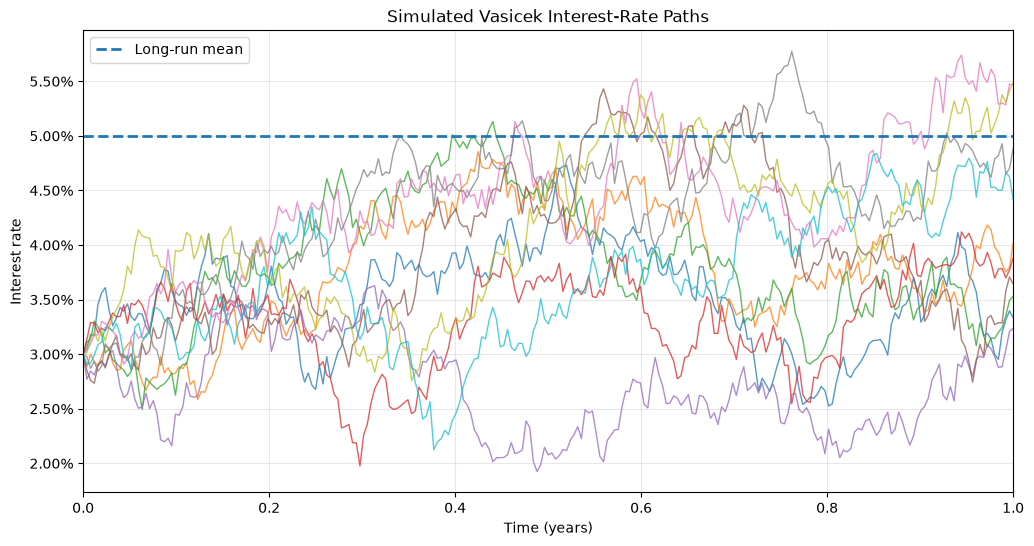

In [8]:
#plotting

plt.figure(figsize=(12, 6))

for column in simulated_paths.columns:
    plt.plot(
        simulated_paths.index,
        simulated_paths[column],
        linewidth=1,
        alpha=0.75
    )

# Plot the long-run mean
plt.axhline(
    y=theta,
    linestyle="--",
    linewidth=2,
    label="Long-run mean"
)

plt.title("Simulated Vasicek Interest-Rate Paths")
plt.xlabel("Time (years)")
plt.ylabel("Interest rate")

plt.xlim(
    simulated_paths.index.min(),
    simulated_paths.index.max()
)

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()

Now since the pipeline works we can actually simulate this form actual bond data.

The current simulation generates daily business-day movements.



In [9]:
#Now we import the files we require

df=pd.read_csv("../data/processed/cleaned_yield_curve.csv")

df.head()

,Date,6M,1Y,2Y,3Y,5Y,7Y,10Y
0,1990-01-02,7.89,7.81,7.87,7.90,7.87,7.98,7.94
1,1990-01-03,7.94,7.85,7.94,7.96,7.92,8.04,7.99
2,1990-01-04,7.90,7.82,7.92,7.93,7.91,8.02,7.98
3,1990-01-05,7.85,7.79,7.90,7.94,7.92,8.03,7.99
4,1990-01-08,7.88,7.81,7.90,7.95,7.92,8.05,8.02


In [10]:
df.tail()

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

In [11]:
#rolling annual rates

df=(df.sort_values("Date").drop_duplicates(subset="Date").reset_index(drop=True))

df.head()



,Date,6M,1Y,2Y,3Y,5Y,7Y,10Y
0,1990-01-02,7.89,7.81,7.87,7.90,7.87,7.98,7.94
1,1990-01-03,7.94,7.85,7.94,7.96,7.92,8.04,7.99
2,1990-01-04,7.90,7.82,7.92,7.93,7.91,8.02,7.98
3,1990-01-05,7.85,7.79,7.90,7.94,7.92,8.03,7.99
4,1990-01-08,7.88,7.81,7.90,7.95,7.92,8.05,8.02


In [12]:
rates_stored_as_percentages = True

# Maximum number of days after the exact anniversary
# that can be used for matching
matching_tolerance_days = 7

# Output location
output_path = (
    Path("..")
    / "data"
    / "processed"
    / "annual_rolling_yield_changes.csv"
)

In [13]:
rates = df.copy()

rates["Date"] = pd.to_datetime(
    rates["Date"],
    errors="coerce"
)

rates = (
    rates
    .dropna(subset=["Date"])
    .sort_values("Date")
    .drop_duplicates(subset=["Date"])
    .reset_index(drop=True)
)

# All columns other than Date are treated as bond maturities
maturity_cols = [
    column
    for column in rates.columns
    if column != "Date"
]

# Convert maturity columns to numeric
rates[maturity_cols] = rates[maturity_cols].apply(
    pd.to_numeric,
    errors="coerce"
)


In [14]:
current_rates = rates.copy()

current_rates["Target_Date"] = (
    current_rates["Date"]
    + pd.DateOffset(years=1)
)

# Remove starting dates for which one-year-ahead data
# cannot possibly exist
last_available_date = rates["Date"].max()

current_rates = current_rates[
    current_rates["Target_Date"] <= last_available_date
].copy()

In [15]:
future_rates = rates.rename(
    columns={
        "Date": "Matched_Date",
        **{
            maturity: f"{maturity}_After_1Y"
            for maturity in maturity_cols
        }
    }
).copy()

In [16]:
annual_rolling = pd.merge_asof(
    current_rates.sort_values("Target_Date"),
    future_rates.sort_values("Matched_Date"),
    left_on="Target_Date",
    right_on="Matched_Date",
    direction="forward",
    tolerance=pd.Timedelta(
        days=matching_tolerance_days
    )
)

# Remove rows where no suitable future date was found
annual_rolling = (
    annual_rolling
    .dropna(subset=["Matched_Date"])
    .reset_index(drop=True)
)

# Number of days after the exact anniversary used
annual_rolling["Matching_Delay_Days"] = (
    annual_rolling["Matched_Date"]
    - annual_rolling["Target_Date"]
).dt.days


In [17]:
bps_multiplier = (
    100
    if rates_stored_as_percentages
    else 10_000
)

for maturity in maturity_cols:

    annual_rolling[f"{maturity}_1Y_Change"] = (
        annual_rolling[f"{maturity}_After_1Y"]
        - annual_rolling[maturity]
    )

    annual_rolling[f"{maturity}_1Y_Change_bps"] = (
        annual_rolling[f"{maturity}_1Y_Change"]
        * bps_multiplier
    )

In [18]:
output_columns = [
    "Date",
    "Target_Date",
    "Matched_Date",
    "Matching_Delay_Days"
]

for maturity in maturity_cols:
    output_columns.extend([
        maturity,
        f"{maturity}_After_1Y",
        f"{maturity}_1Y_Change",
        f"{maturity}_1Y_Change_bps"
    ])

annual_rolling = annual_rolling[output_columns]


In [19]:
output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

annual_rolling.to_csv(
    output_path,
    index=False
)

In [20]:
print(f"File saved to: {output_path}")

print(
    "\nOriginal date range:",
    rates["Date"].min(),
    "to",
    rates["Date"].max()
)

print(
    "\nUsable starting-date range:",
    annual_rolling["Date"].min(),
    "to",
    annual_rolling["Date"].max()
)

print(
    "\nMaximum matching delay:",
    annual_rolling["Matching_Delay_Days"].max(),
    "days"
)

annual_rolling.head()

File saved to: ..\data\processed\annual_rolling_yield_changes.csv

Original date range: 1990-01-02 00:00:00 to 2023-12-29 00:00:00

Usable starting-date range: 1990-01-02 00:00:00 to 2022-12-29 00:00:00

Maximum matching delay: 3 days


,Date,Target_Date,Matched_Date,Matching_Delay_Days,6M,6M_After_1Y,6M_1Y_Change,6M_1Y_Change_bps,1Y,1Y_After_1Y,...,5Y_1Y_Change,5Y_1Y_Change_bps,7Y,7Y_After_1Y,7Y_1Y_Change,7Y_1Y_Change_bps,10Y,10Y_After_1Y,10Y_1Y_Change,10Y_1Y_Change_bps
0,1990-01-02,1991-01-02,1991-01-02,0,7.89,6.73,-1.16,-116.0,7.81,6.74,...,-0.28,-28.0,7.98,7.90,-0.08,-8.0,7.94,7.97,0.03,3.0
1,1990-01-03,1991-01-03,1991-01-03,0,7.94,6.71,-1.23,-123.0,7.85,6.72,...,-0.36,-36.0,8.04,7.86,-0.18,-18.0,7.99,7.93,-0.06,-6.0
2,1990-01-04,1991-01-04,1991-01-04,0,7.90,6.82,-1.08,-108.0,7.82,6.83,...,-0.26,-26.0,8.02,7.94,-0.08,-8.0,7.98,8.02,0.04,4.0
3,1990-01-05,1991-01-05,1991-01-07,2,7.85,6.84,-1.01,-101.0,7.79,6.84,...,-0.17,-17.0,8.03,8.04,0.01,1.0,7.99,8.13,0.14,14.0
4,1990-01-08,1991-01-08,1991-01-08,0,7.88,6.74,-1.14,-114.0,7.81,6.75,...,-0.18,-18.0,8.05,8.06,0.01,1.0,8.02,8.16,0.14,14.0


In [21]:
annual_rolling.shape
annual_rolling.columns

Index(['Date', 'Target_Date', 'Matched_Date', 'Matching_Delay_Days', '6M',
       '6M_After_1Y', '6M_1Y_Change', '6M_1Y_Change_bps', '1Y', '1Y_After_1Y',
       '1Y_1Y_Change', '1Y_1Y_Change_bps', '2Y', '2Y_After_1Y', '2Y_1Y_Change',
       '2Y_1Y_Change_bps', '3Y', '3Y_After_1Y', '3Y_1Y_Change',
       '3Y_1Y_Change_bps', '5Y', '5Y_After_1Y', '5Y_1Y_Change',
       '5Y_1Y_Change_bps', '7Y', '7Y_After_1Y', '7Y_1Y_Change',
       '7Y_1Y_Change_bps', '10Y', '10Y_After_1Y', '10Y_1Y_Change',
       '10Y_1Y_Change_bps'],
      dtype='str')

In [22]:
rolling_change_columns = [
    column
    for column in annual_rolling.columns
    if column.endswith("_1Y_Change")
]

rolling_changes = annual_rolling[
    ["Date"] + rolling_change_columns
].copy()

rolling_changes.head()


,Date,6M_1Y_Change,1Y_1Y_Change,2Y_1Y_Change,3Y_1Y_Change,5Y_1Y_Change,7Y_1Y_Change,10Y_1Y_Change
0,1990-01-02,-1.16,-1.07,-0.79,-0.60,-0.28,-0.08,0.03
1,1990-01-03,-1.23,-1.13,-0.86,-0.69,-0.36,-0.18,-0.06
2,1990-01-04,-1.08,-0.99,-0.75,-0.56,-0.26,-0.08,0.04
3,1990-01-05,-1.01,-0.95,-0.70,-0.51,-0.17,0.01,0.14
4,1990-01-08,-1.14,-1.06,-0.75,-0.56,-0.18,0.01,0.14


In [23]:
rolling_changes.tail()

rolling_changes.to_csv(
    "../data/processed/annual_rolling_changes.csv",
    index=False
)

Now we do the MLE estimation    

In [24]:
print(rates.columns.tolist())

['Date', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y']


In [25]:
def fit_vasicek_mle(
    data,
    maturity,
    date_column="Date",
    rates_are_percent=True
):
    """
    Estimate a univariate Vasicek model using exact maximum likelihood.

    Model:
        dr_t = kappa * (theta - r_t) * dt + sigma * dW_t

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame containing dates and one yield maturity.

    maturity : str
        Name of the yield column, such as "6M" or "1Y".

    date_column : str
        Name of the date column.

    rates_are_percent : bool
        True when 7.5 means 7.5%.
        False when 0.075 means 7.5%.

    Returns
    -------
    parameters : dict
        Estimated kappa, theta and sigma.

    residual_table : pandas.DataFrame
        Actual values, fitted means and standardized residuals.
    """

    model_data = data[
        [date_column, maturity]
    ].copy()

    model_data[date_column] = pd.to_datetime(
        model_data[date_column],
        errors="coerce"
    )

    model_data[maturity] = pd.to_numeric(
        model_data[maturity],
        errors="coerce"
    )

    model_data = (
        model_data
        .dropna()
        .sort_values(date_column)
        .drop_duplicates(subset=date_column)
        .reset_index(drop=True)
    )

    if len(model_data) < 20:
        raise ValueError(
            f"Not enough observations for {maturity}."
        )

    rates = model_data[maturity].to_numpy(
        dtype=float
    )

    # Convert percentage yields into decimal yields.
    # Example: 7.5 becomes 0.075.
    if rates_are_percent:
        rates = rates / 100

    dates = model_data[date_column].to_numpy(
        dtype="datetime64[D]"
    )

    r_t = rates[:-1]
    r_next = rates[1:]

    start_dates = dates[:-1]
    end_dates = dates[1:]

    # Number of business days between consecutive observations.
    business_day_gaps = np.array([
        np.busday_count(start, end)
        for start, end in zip(
            start_dates,
            end_dates
        )
    ])

    # Avoid zero time intervals.
    valid = business_day_gaps > 0

    r_t = r_t[valid]
    r_next = r_next[valid]
    business_day_gaps = business_day_gaps[valid]

    start_dates = start_dates[valid]
    end_dates = end_dates[valid]

    # Express time intervals in years.
    delta_t = business_day_gaps / 252

    if len(r_t) < 20:
        raise ValueError(
            f"Not enough valid transitions for {maturity}."
        )

    def negative_log_likelihood(parameters):
        """
        Parameters are transformed so that:
            kappa > 0
            sigma > 0
        """

        log_kappa, theta, log_sigma = parameters

        kappa = np.exp(log_kappa)
        sigma = np.exp(log_sigma)

        phi = np.exp(-kappa * delta_t)

        conditional_mean = (
            theta
            +
            (r_t - theta) * phi
        )

        conditional_variance = (
            sigma ** 2
            *
            (1 - phi ** 2)
            /
            (2 * kappa)
        )

        # Protect against numerical problems.
        if np.any(conditional_variance <= 0):
            return np.inf

        residuals = (
            r_next - conditional_mean
        )

        log_likelihood_terms = (
            -0.5
            * (
                np.log(
                    2
                    * np.pi
                    * conditional_variance
                )
                +
                residuals ** 2
                /
                conditional_variance
            )
        )

        return -np.sum(log_likelihood_terms)

    # Initial parameter estimates
    theta_initial = np.mean(rates)

    daily_changes = np.diff(rates)

    sigma_initial = (
        np.std(daily_changes, ddof=1)
        * np.sqrt(252)
    )

    if (
        not np.isfinite(sigma_initial)
        or sigma_initial <= 0
    ):
        sigma_initial = 0.01

    kappa_initial = 0.50

    initial_parameters = np.array([
        np.log(kappa_initial),
        theta_initial,
        np.log(sigma_initial)
    ])

    optimization_result = minimize(
        negative_log_likelihood,
        initial_parameters,
        method="L-BFGS-B"
    )

    if not optimization_result.success:
        raise RuntimeError(
            f"MLE failed for {maturity}: "
            f"{optimization_result.message}"
        )

    log_kappa_estimate, theta_estimate, log_sigma_estimate = (
        optimization_result.x
    )

    kappa_estimate = np.exp(
        log_kappa_estimate
    )

    sigma_estimate = np.exp(
        log_sigma_estimate
    )

    phi = np.exp(
        -kappa_estimate * delta_t
    )

    fitted_mean = (
        theta_estimate
        +
        (r_t - theta_estimate)
        * phi
    )

    fitted_variance = (
        sigma_estimate ** 2
        *
        (1 - phi ** 2)
        /
        (2 * kappa_estimate)
    )

    fitted_standard_deviation = np.sqrt(
        fitted_variance
    )

    residuals = r_next - fitted_mean

    standardized_residuals = (
        residuals
        /
        fitted_standard_deviation
    )

    log_likelihood = (
        -optimization_result.fun
    )

    number_of_parameters = 3

    aic = (
        2 * number_of_parameters
        -
        2 * log_likelihood
    )

    half_life_years = (
        np.log(2)
        /
        kappa_estimate
    )

    parameters = {
        "Maturity": maturity,
        "Number_of_Observations": len(r_t),
        "Kappa": kappa_estimate,
        "Theta": theta_estimate,
        "Sigma": sigma_estimate,
        "Theta_Percent": theta_estimate * 100,
        "Sigma_Percent": sigma_estimate * 100,
        "Half_Life_Years": half_life_years,
        "Half_Life_Business_Days":
            half_life_years * 252,
        "Log_Likelihood": log_likelihood,
        "AIC": aic,
        "Optimization_Success":
            optimization_result.success
    }

    residual_table = pd.DataFrame({
        "Start_Date": pd.to_datetime(
            start_dates
        ),
        "End_Date": pd.to_datetime(
            end_dates
        ),
        "Business_Day_Gap":
            business_day_gaps,
        "r_t": r_t,
        "r_next": r_next,
        "Conditional_Mean":
            fitted_mean,
        "Conditional_SD":
            fitted_standard_deviation,
        "Residual": residuals,
        "Squared_Residual":
            residuals ** 2,
        "Standardized_Residual":
            standardized_residuals
    })

    return parameters, residual_table

At a high level, it does four main things:

Prepares the data

Selects the date column and one maturity column from the input table.
Converts dates to proper datetime values and yields to numeric values.
Sorts the data chronologically and removes missing or duplicate entries.
Builds transition data

Treats each observation as a pair: the rate at time 
t
t and the rate at the next observation time.
Computes the number of business days between those dates and converts that into a time step in years.
Estimates model parameters

Assumes the rate follows a Vasicek process:
mean reversion toward a long-run level
random shocks with Gaussian noise
Uses numerical optimization to estimate:
κ
κ: speed of mean reversion
θ
θ: long-run mean rate
σ
σ: volatility
Produces outputs

Returns a parameter dictionary with the estimated values and fit statistics such as log-likelihood and AIC.
Returns a residual table with the actual rates, fitted means, residuals, and standardized residuals for checking model fit.

6 Month

In [26]:
parameters_6m, residuals_6m = (
    fit_vasicek_mle(
        data=rates,
        maturity="6M",
        date_column="Date",
        rates_are_percent=True
    )
)

pd.Series(parameters_6m)

Maturity                             6M
Number_of_Observations             8505
Kappa                          0.089375
Theta                          0.019726
Sigma                          0.006333
Theta_Percent                  1.972639
Sigma_Percent                  0.633304
Half_Life_Years                7.755535
Half_Life_Business_Days     1954.394767
Log_Likelihood              54373.85733
AIC                       -108741.71466
Optimization_Success               True
dtype: object

In [27]:
kappa_6m = parameters_6m["Kappa"]
theta_6m = parameters_6m["Theta"]
sigma_6m = parameters_6m["Sigma"]

In [28]:
print(f"6M kappa: {kappa_6m:.6f}")

print(
    f"6M long-run mean: "
    f"{theta_6m:.4%}"
)

print(
    f"6M annual volatility: "
    f"{sigma_6m:.4%}"
)

print(
    f"6M half-life: "
    f"{parameters_6m['Half_Life_Business_Days']:.2f} "
    f"business days"
)

6M kappa: 0.089375
6M long-run mean: 1.9726%
6M annual volatility: 0.6333%
6M half-life: 1954.39 business days


In [29]:
print(
    "Standardized residual mean:",
    residuals_6m[
        "Standardized_Residual"
    ].mean()
)

print(
    "Standardized residual standard deviation:",
    residuals_6m[
        "Standardized_Residual"
    ].std(ddof=0)
)

Standardized residual mean: -0.005822040710525342
Standardized residual standard deviation: 0.9999805975312664


In [30]:
residuals_6m.head()

,Start_Date,End_Date,Business_Day_Gap,r_t,r_next,Conditional_Mean,Conditional_SD,Residual,Squared_Residual,Standardized_Residual
0,1990-01-02,1990-01-03,1,0.0789,0.0794,0.078879,0.000399,0.000521,2.714231e-07,1.306137
1,1990-01-03,1990-01-04,1,0.0794,0.0790,0.079379,0.000399,-0.000379,1.435196e-07,-0.949776
2,1990-01-04,1990-01-05,1,0.0790,0.0785,0.078979,0.000399,-0.000479,2.294235e-07,-1.200837
3,1990-01-05,1990-01-08,1,0.0785,0.0788,0.078479,0.000399,0.000321,1.029389e-07,0.804369
4,1990-01-08,1990-01-09,1,0.0788,0.0782,0.078779,0.000399,-0.000579,3.353019e-07,-1.451722


1 Year

In [31]:
parameters_1y, residuals_1y = (
    fit_vasicek_mle(
        data=rates,
        maturity="1Y",
        date_column="Date",
        rates_are_percent=True
    )
)

pd.Series(parameters_1y)



Maturity                              1Y
Number_of_Observations              8505
Kappa                           0.099613
Theta                           0.020643
Sigma                           0.006989
Theta_Percent                   2.064284
Sigma_Percent                   0.698894
Half_Life_Years                 6.958389
Half_Life_Business_Days       1753.51409
Log_Likelihood              53535.859052
AIC                       -107065.718103
Optimization_Success                True
dtype: object

In [32]:
kappa_1y = parameters_1y["Kappa"]
theta_1y = parameters_1y["Theta"]
sigma_1y = parameters_1y["Sigma"]

2 year

In [33]:
parameters_2y, residuals_2y = (
    fit_vasicek_mle(
        data=rates,
        maturity="2Y",
        date_column="Date",
        rates_are_percent=True
    )
)

pd.Series(parameters_2y)

Maturity                              2Y
Number_of_Observations              8505
Kappa                           0.125565
Theta                           0.023676
Sigma                           0.008726
Theta_Percent                    2.36755
Sigma_Percent                   0.872626
Half_Life_Years                 5.520211
Half_Life_Business_Days      1391.093255
Log_Likelihood              51648.138896
AIC                       -103290.277792
Optimization_Success                True
dtype: object

In [34]:
parameters_2y, residuals_2y = (
    fit_vasicek_mle(
        data=rates,
        maturity="2Y",
        date_column="Date",
        rates_are_percent=True
    )
)

pd.Series(parameters_2y)

Maturity                              2Y
Number_of_Observations              8505
Kappa                           0.125565
Theta                           0.023676
Sigma                           0.008726
Theta_Percent                    2.36755
Sigma_Percent                   0.872626
Half_Life_Years                 5.520211
Half_Life_Business_Days      1391.093255
Log_Likelihood              51648.138896
AIC                       -103290.277792
Optimization_Success                True
dtype: object

In [48]:
kappa_2y = parameters_2y["Kappa"]
theta_2y = parameters_2y["Theta"]
sigma_2y = parameters_2y["Sigma"]

3 years

In [35]:
parameters_3y, residuals_3y = (
    fit_vasicek_mle(
        data=rates,
        maturity="3Y",
        date_column="Date",
        rates_are_percent=True
    )
)

pd.Series(parameters_3y)

Maturity                             3Y
Number_of_Observations             8505
Kappa                           0.13666
Theta                          0.025787
Sigma                          0.009172
Theta_Percent                  2.578746
Sigma_Percent                  0.917206
Half_Life_Years                5.072063
Half_Life_Business_Days     1278.159987
Log_Likelihood             51224.505615
AIC                       -102443.01123
Optimization_Success               True
dtype: object

In [36]:
kappa_3y = parameters_3y["Kappa"]
theta_3y = parameters_3y["Theta"]
sigma_3y = parameters_3y["Sigma"]

5 years

In [37]:
parameters_5y, residuals_5y = (
    fit_vasicek_mle(
        data=rates,
        maturity="5Y",
        date_column="Date",
        rates_are_percent=True
    )
)

pd.Series(parameters_5y)

Maturity                              5Y
Number_of_Observations              8505
Kappa                           0.149075
Theta                           0.029766
Sigma                           0.009568
Theta_Percent                   2.976623
Sigma_Percent                    0.95678
Half_Life_Years                 4.649666
Half_Life_Business_Days      1171.715784
Log_Likelihood              50865.523277
AIC                       -101725.046554
Optimization_Success                True
dtype: object

In [38]:
kappa_5y = parameters_5y["Kappa"]
theta_5y = parameters_5y["Theta"]
sigma_5y = parameters_5y["Sigma"]

7 year

In [43]:
parameters_7y, residuals_7y = (
    fit_vasicek_mle(
        data=rates,
        maturity="7Y",
        date_column="Date",
        rates_are_percent=True
    )
)

pd.Series(parameters_7y)

Maturity                              7Y
Number_of_Observations              8505
Kappa                           0.155641
Theta                           0.032829
Sigma                           0.009557
Theta_Percent                   3.282857
Sigma_Percent                   0.955701
Half_Life_Years                 4.453505
Half_Life_Business_Days      1122.283229
Log_Likelihood              50875.215644
AIC                       -101744.431288
Optimization_Success                True
dtype: object

In [44]:
kappa_7y = parameters_7y["Kappa"]
theta_7y = parameters_7y["Theta"]
sigma_7y = parameters_7y["Sigma"]

10 year

In [45]:
parameters_10y, residuals_10y = (
    fit_vasicek_mle(
        data=rates,
        maturity="10Y",
        date_column="Date",
        rates_are_percent=True
    )
)

pd.Series(parameters_10y)

Maturity                             10Y
Number_of_Observations              8505
Kappa                           0.152369
Theta                           0.034931
Sigma                             0.0091
Theta_Percent                   3.493101
Sigma_Percent                   0.909985
Half_Life_Years                 4.549138
Half_Life_Business_Days      1146.382872
Log_Likelihood              51292.082131
AIC                       -102578.164263
Optimization_Success                True
dtype: object

In [41]:
kappa_10y = parameters_10y["Kappa"]
theta_10y = parameters_10y["Theta"]
sigma_10y = parameters_10y["Sigma"]

Together

In [49]:
all_parameter_results = pd.DataFrame([
    parameters_6m,
    parameters_1y,
    parameters_2y,
    parameters_3y,
    parameters_5y,
    parameters_7y,
    parameters_10y
])

all_parameter_results[
    [
        "Maturity",
        "Number_of_Observations",
        "Kappa",
        "Theta_Percent",
        "Sigma_Percent",
        "Half_Life_Business_Days",
        "Log_Likelihood",
        "AIC"
    ]
]

,Maturity,Number_of_Observations,Kappa,Theta_Percent,Sigma_Percent,Half_Life_Business_Days,Log_Likelihood,AIC
0,6M,8505,0.089375,1.972639,0.633304,1954.394767,54373.857330,-108741.714660
1,1Y,8505,0.099613,2.064284,0.698894,1753.514090,53535.859052,-107065.718103
2,2Y,8505,0.125565,2.367550,0.872626,1391.093255,51648.138896,-103290.277792
3,3Y,8505,0.136660,2.578746,0.917206,1278.159987,51224.505615,-102443.011230
4,5Y,8505,0.149075,2.976623,0.956780,1171.715784,50865.523277,-101725.046554
5,7Y,8505,0.155641,3.282857,0.955701,1122.283229,50875.215644,-101744.431288
6,10Y,8505,0.152369,3.493101,0.909985,1146.382872,51292.082131,-102578.164263


In [47]:
all_parameter_results.to_csv(
    "single_maturity_vasicek_parameters.csv",
    index=False
)

In [50]:
# Starting rate: latest observed 6M yield
r0_6m = rates["6M"].dropna().iloc[-1] / 100

# Simulation settings
T = 1.0
steps_per_year = 252
num_paths = 10000
seed = 42

simulated_paths_6m = simulate_vasicek_paths(
    kappa=kappa_6m,
    theta=theta_6m,
    sigma=sigma_6m,
    r0=r0_6m,
    T=T,
    steps_per_year=steps_per_year,
    num_paths=num_paths,
    seed=seed
)

simulated_paths_6m.head()

,Path 1,Path 2,Path 3,Path 4,Path 5,Path 6,Path 7,Path 8,Path 9,Path 10,...,Path 9991,Path 9992,Path 9993,Path 9994,Path 9995,Path 9996,Path 9997,Path 9998,Path 9999,Path 10000
Time (years),,,,,,,,,,,,,,,,,,,,,
0.000000,0.052600,0.052600,0.052600,0.052600,0.052600,0.052600,0.052600,0.052600,0.052600,0.052600,...,0.052600,0.052600,0.052600,0.052600,0.052600,0.052600,0.052600,0.052600,0.052600,0.052600
0.003968,0.052710,0.052173,0.052888,0.052964,0.051810,0.052069,0.052639,0.052462,0.052582,0.052248,...,0.052758,0.051855,0.052377,0.052866,0.052338,0.053235,0.052563,0.052622,0.053037,0.052515
0.007937,0.052769,0.052521,0.052289,0.052838,0.052129,0.052084,0.053213,0.051822,0.051896,0.052544,...,0.053360,0.051824,0.052577,0.052561,0.051942,0.053927,0.052228,0.052867,0.053237,0.052973
0.011905,0.052095,0.052865,0.052254,0.052587,0.052018,0.052486,0.053493,0.051759,0.051430,0.052106,...,0.053875,0.051454,0.053056,0.052617,0.051633,0.054003,0.052292,0.053600,0.053377,0.052649
0.015873,0.051680,0.052834,0.051705,0.052290,0.051909,0.052306,0.053771,0.051454,0.050433,0.051422,...,0.053822,0.052151,0.053633,0.052977,0.051239,0.053585,0.051843,0.054197,0.053002,0.052484
